In [193]:
# General imports
import pickle
import numpy as np
import pandas as pd
from matplotlib import rc
from matplotlib import pyplot as plt

# Sklearn imports
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [194]:
# Convert a 1D array to a 2D array
def convert(array):
    length = len(array)
    new_shape = (length, 1)
    array = np.reshape(array, new_shape)
    return array

In [195]:
# Depickle: Training
TRAINING_FILE = open('data/train.pkl', 'rb')
train_data = pickle.load(TRAINING_FILE)

# Depickle: Testing
TESTING_FILE = open('data/test.pkl', 'rb')
test_data = pickle.load(TESTING_FILE)

In [196]:
# Extract arrays and convert to 2D
X_train = convert(train_data[:,0])
Y_train = convert(train_data[:,1])
X_test = convert(test_data[:,0])
Y_test = convert(test_data[:,1])

In [197]:
# Display training and testing data
print("Train data shape : ", train_data.shape)
print("Test data shape  : ", test_data.shape)
print()

print("Train data sample")
print(train_data[:3])
print()

print("Test data sample")
print(test_data[:3])

Train data shape :  (8000, 2)
Test data shape  :  (80, 2)

Train data sample
[[  27.42765666 3335.78295109]
 [  -4.96183456 2647.40265244]
 [ -27.86119551  520.73369536]]

Test data sample
[[  -15.029       -351.99223091]
 [  -25.977      -1807.03436449]
 [   -4.48          -9.00368   ]]


In [198]:
# Definitions
GRAPH_SIZE = (20, 12)
NUM_DATASETS = 16
TOTAL_SIZE = len(train_data)
DATASET_SIZE = int(TOTAL_SIZE/NUM_DATASETS)
LOWEST_ORDER = 1
HIGHEST_ORDER = 15
NUM_ORDERS = HIGHEST_ORDER - LOWEST_ORDER + 1
FONT = {
    'family': 'sans',
    'weight': 'normal',
    'size': 16
}
rc('font', **FONT)

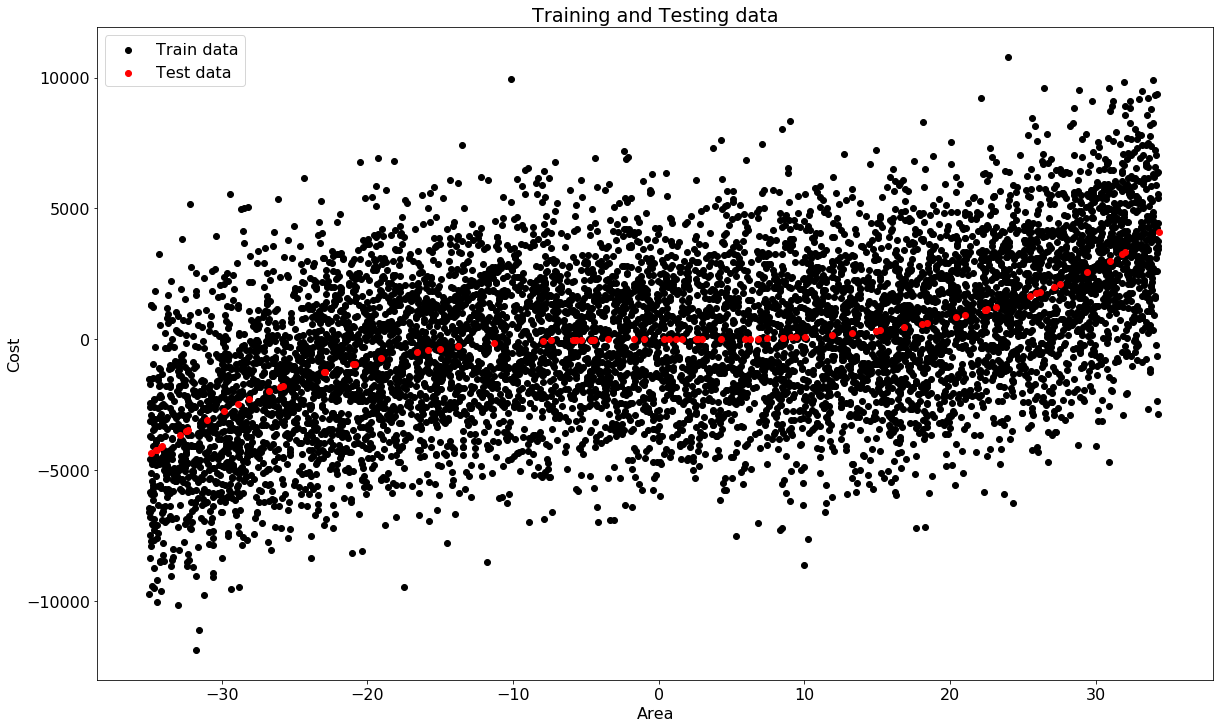

In [199]:
# Plot the graph
plt.figure(figsize=GRAPH_SIZE)
plt.title('Training and Testing data', )
plt.xlabel('Area')
plt.ylabel('Cost')

plt.scatter(X_train, Y_train, label="Train data", color='black')
plt.scatter(X_test , Y_test,  label="Test data" , color='red')

plt.legend()
plt.show()

In [200]:
# Separate the dataset
np.random.shuffle(train_data)
train_sets = np.split(train_data, NUM_DATASETS)
print(train_sets[0][:5])

[[   28.50103374  3916.33064258]
 [  -15.23871973 -1228.05933927]
 [   11.70822199  2672.66932537]
 [   15.12085429 -1501.95299392]
 [   21.08155501  2037.04870184]]


In [201]:
# Train the models
models = []
functions = []

# Iterate throught the polynomial orders
for order in range(LOWEST_ORDER, HIGHEST_ORDER + 1):
    index = order - LOWEST_ORDER
    
    # Add an empty list that will eventually store 16 different models for 16 different datasets,
    # all corresponding to a polynomial of order {order}
    models.append([])
    functions.append([])
    
    # Iterate throught the datasets
    for train_set in train_sets:
        x_train = convert(train_set[:,0])
        y_train = convert(train_set[:,1])
        
        poly = PolynomialFeatures(order)
        x_train = poly.fit_transform(x_train)
        
        regmodel = LinearRegression().fit(x_train, y_train)
        
        models[index].append(regmodel)
        functions[index].append(poly)

In [202]:
# Obtain the predictions from each model
predictions = []
test_data = np.sort(test_data, axis = 0)
for order in range(LOWEST_ORDER, HIGHEST_ORDER + 1):
    index = order - LOWEST_ORDER
    predictions.append([])
    
    for i in range(NUM_DATASETS):
        x_test = convert(test_data[:,0])
        x_test = functions[index][i].transform(x_test)
        predictions[index].append(models[index][i].predict(x_test))

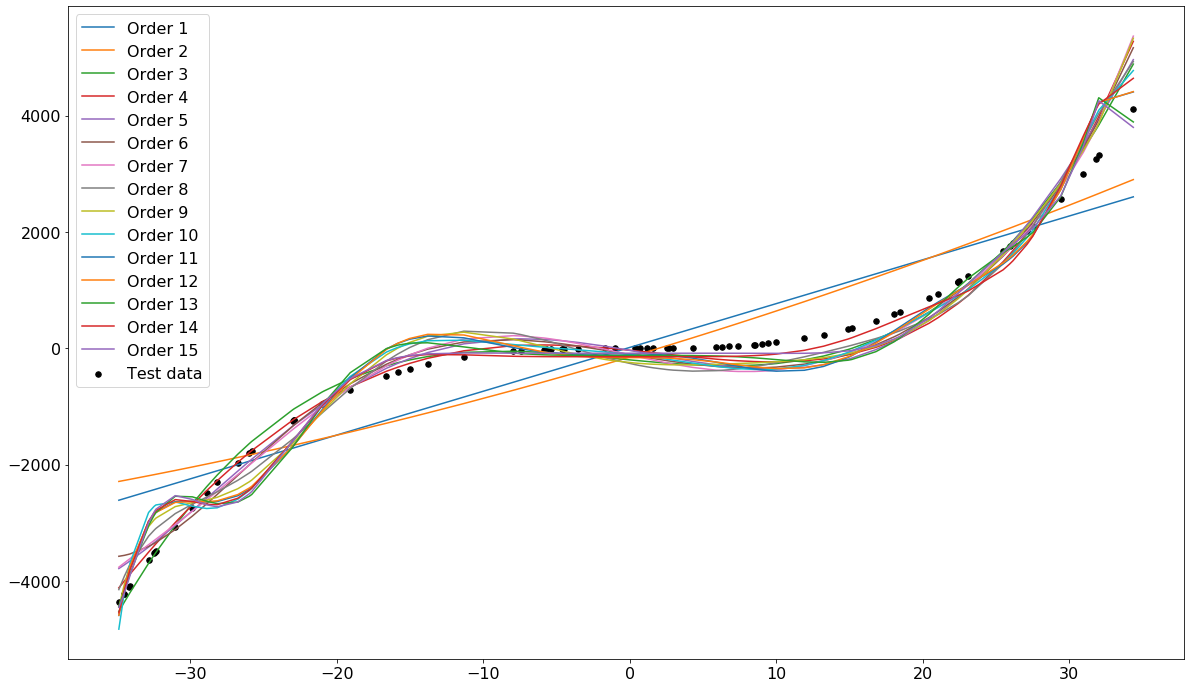

In [203]:
# Plotting a graph for every polynomial degree
plt.figure(figsize=GRAPH_SIZE)
plt.scatter(X_test, Y_test, s=30, color='black', label='Test data')
for order in range(LOWEST_ORDER, HIGHEST_ORDER + 1):
    index = order - LOWEST_ORDER
    
    for train_set in range(1):
        x_test = convert(test_data[:,0])
        plt.plot(x_test, predictions[index][train_set], label='Order '+str(order))
plt.legend()

In [204]:
# Calculating average predictions (expectation)
np.set_printoptions(suppress=True)
average_pred = []

for order in range(LOWEST_ORDER, HIGHEST_ORDER + 1):
    index = order - LOWEST_ORDER
    av_pred = np.mean(predictions[index], axis=0)
    average_pred.append(av_pred)

In [205]:
# Lists to hold our squared bias, variance, MSE and IRE
bias_square = []
variance = []
mean_squared_error = []
irreducible_error = []
print(len(predictions[2]))

# Finding bias, variance and MSE for every order
for order in range(LOWEST_ORDER, HIGHEST_ORDER + 1):
    index = order - LOWEST_ORDER
    
    # Appended values
    var = 0
    bias = np.mean((average_pred[index] - np.split(test_data, 2, axis=1)[1])**2)
    mse = 0

    # Finding variance and MSE
    for train_set in range(NUM_DATASETS):
        test_var = np.mean((average_pred[index] - predictions[index][train_set])**2)
        test_mse = np.mean((predictions[index][train_set] - np.split(test_data, 2, axis=1)[1])**2)

        var += test_var
        mse += test_mse

    var /= NUM_DATASETS
    mse /= NUM_DATASETS

    bias_square.append(bias)
    variance.append(var)
    mean_squared_error.append(mse)
    irreducible_error.append(mse - bias - var)

#tabulating IRE
table = pd.DataFrame(irreducible_error)
table.columns = ['Irreducible error']
table.index = range(0, NUM_ORDERS)
table


16


,Irreducible error
0,-1.091394e-10
1,0.000000e+00
2,0.000000e+00
3,-1.455192e-11
4,-4.365575e-11
5,0.000000e+00
6,8.731149e-11
7,5.820766e-11
8,2.910383e-11
9,0.000000e+00


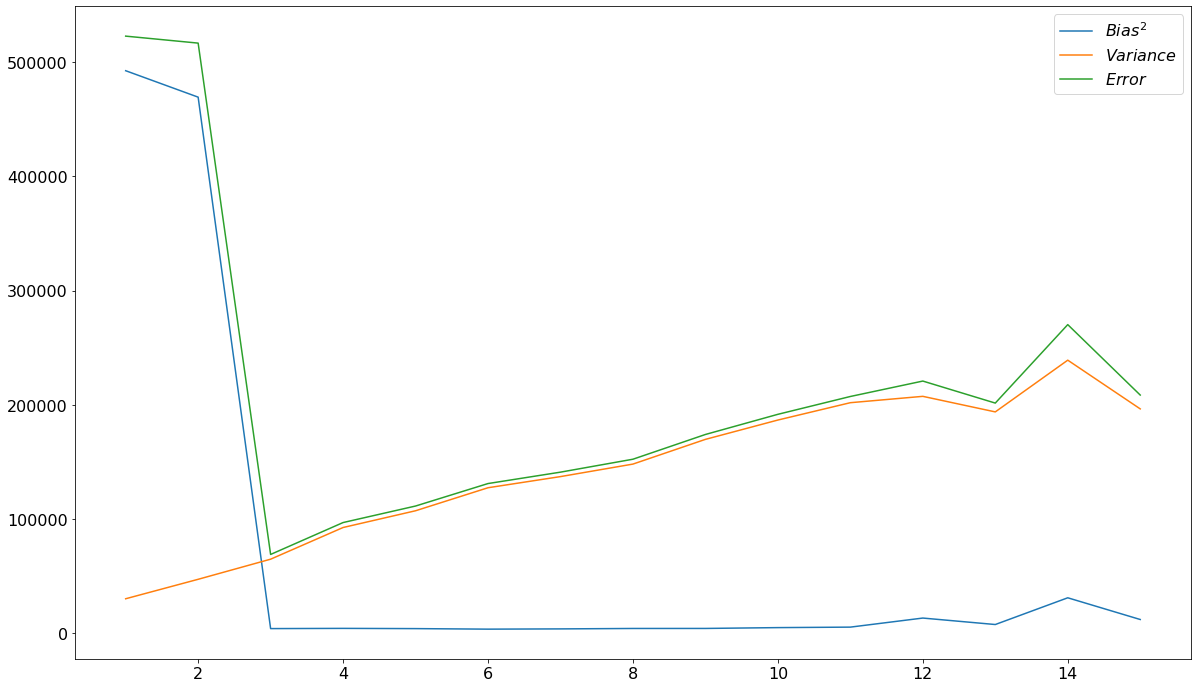

In [206]:
#Plotting Bias^2 - Variance Graph
x = [i for i in range(LOWEST_ORDER, HIGHEST_ORDER + 1)]
plt.figure(figsize=GRAPH_SIZE)
plt.plot(x, bias_square, label="$Bias^2$")
plt.plot(x, variance, label="$Variance$")
plt.plot(x, mean_squared_error, label="$Error$")
plt.legend()